In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)


In [2]:
import nambu_class as nmb
import Eilenberger_methods as eil
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt

In [7]:
ntheta = 10
cutoff = 30 * eil.EilenbergerEvolution.get_bcs_ratio()
nw = 500

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* eil.EilenbergerEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'theta_sampling': ntheta, 'cutoff': cutoff}
system_parameters = {'critical_temperature': 1.0, 'gap_symmetry' : 's', 'average_indices': (2,3)}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 200}
sigma_scatterings = {'Elastic': 10.0, 'Dynes': 5.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_eil = eil.EilenbergerEvolution(grid_parameters, system_parameters, sigma_scatterings = sigma_scatterings, optimization_parameters = optimization_parameters)
temperatures = jnp.linspace(0.01,1.2,10)
print(temperatures)

[0.01       0.14222223 0.27444446 0.4066667  0.53888893 0.67111117
 0.8033334  0.9355556  1.0677779  1.2       ]


In [8]:
gap_list = []
#for temp in tqdm(temperatures):
gaps = comp.calculate_equilibrium(temp_list = temperatures, grid_parameters = grid_parameters, system_parameters = system_parameters, Q_list = [0], sigma_scatterings = sigma_scatterings, optimization_parameters=optimization_parameters)  
gap_list +=[gaps]


  0%|          | 0/10 [00:00<?, ?it/s]

{'custom_jac': False, 'tol': 0.001, 'maxiter': 200}


 30%|███       | 3/10 [00:01<00:02,  2.38it/s]

(1.7512497-0j)
(1.7507216-0j)
(1.7447717-0j)
(1.7149725-0j)


 70%|███████   | 7/10 [00:01<00:00,  6.33it/s]

(1.6311313-0j)
(1.4754682-0j)
(1.2011007-0j)
(0.6809483-0j)


100%|██████████| 10/10 [00:01<00:00,  5.01it/s]

(0.048389405-0j)
(0.00010943283-0j)


In [5]:
print(gaps)

[Array(1.7535565-0.j, dtype=complex64), Array(1.753503-0.j, dtype=complex64), Array(1.7533742-0.j, dtype=complex64), Array(1.7531551-0.j, dtype=complex64), Array(1.7527652-0.j, dtype=complex64), Array(1.7510492-0.j, dtype=complex64), Array(1.7489135-0.j, dtype=complex64), Array(1.7446014-0.j, dtype=complex64), Array(1.7375251-0.j, dtype=complex64), Array(1.7279642-0.j, dtype=complex64), Array(1.7135419-0.j, dtype=complex64), Array(1.6915157-0.j, dtype=complex64), Array(1.6661919-0.j, dtype=complex64), Array(1.6338242-0.j, dtype=complex64), Array(1.5931346-0.j, dtype=complex64), Array(1.5431961-0.j, dtype=complex64), Array(1.4869496-0.j, dtype=complex64), Array(1.4187212-0.j, dtype=complex64), Array(1.3376399-0.j, dtype=complex64), Array(1.24275-0.j, dtype=complex64), Array(1.1295264-0.j, dtype=complex64), Array(0.9914107-0.j, dtype=complex64), Array(0.8175272-0.j, dtype=complex64), Array(0.5841214-0.j, dtype=complex64), Array(0.24621573-0.j, dtype=complex64), Array(0.08059727-0.j, dtyp

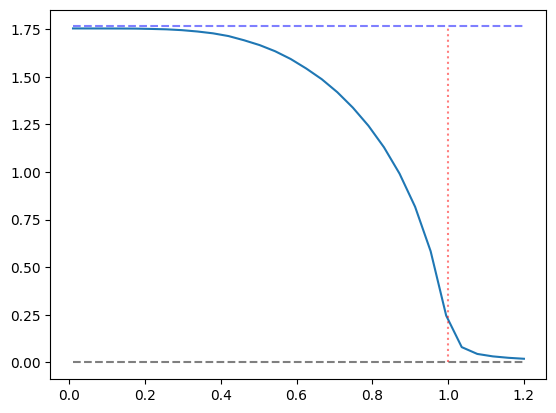

In [6]:
plt.plot(temperatures,jnp.abs(jnp.array(gaps)))
plt.hlines(0.0,temperatures[0],temperatures[-1], 'k', 'dashed',alpha = 0.5)
plt.hlines(my_eil.get_bcs_ratio(),temperatures[0],temperatures[-1], 'b', 'dashed',alpha = 0.5)
plt.vlines(1.0,0.0,my_eil.get_bcs_ratio(), 'r', 'dotted',alpha = 0.5)

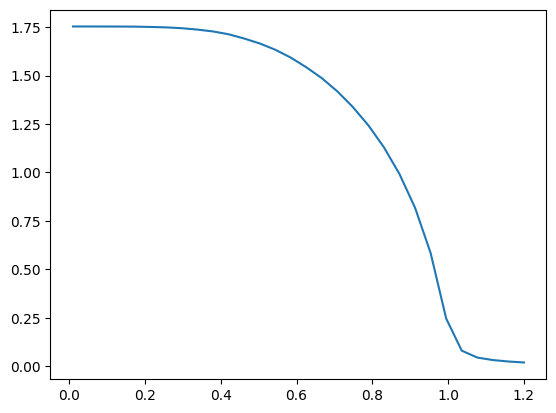

In [7]:
plt.plot(temperatures,jnp.abs(jnp.array(gaps[:])))

In [28]:
def custom_inverse(other_list, v_list = [], u_list = [], block_diagonal = []):
    #matrix sum other_list + sum(np.outer(v_list[i],u_list[i]) for i in range(len(v_list)))
    if v_list.size != 0 and u_list.size != 0:
        rest_inv = custom_inverse(other_list = other_list, v_list = v_list[1:], u_list = u_list[1:], block_diagonal = block_diagonal)
        return  rest_inv  - jnp.outer((rest_inv @ u_list[0]), v_list[0] @ rest_inv)/ (1 + v_list[0] @ rest_inv @ u_list[0])
    else:
        return jnp.linalg.inv(jnp.sum(other_list, axis = 0) + jnp.sum(block_diagonal, axis = 0))
    

In [40]:
key = jax.random.PRNGKey(0)
other_list = jnp.array([jax.random.normal(key, (3, 3))])
v_list = jnp.array([jax.random.normal(key, 3)])
u_list = jnp.array([jax.random.normal(key, 3)])
block_diagonal = jnp.array([])
full_matrix = jnp.sum(other_list, axis = 0) + jnp.sum(block_diagonal, axis = 0) + jnp.outer(v_list[0],u_list[0])
full_inverse = jnp.linalg.inv(full_matrix)
my_inverse = custom_inverse(other_list = other_list, v_list = v_list, u_list = u_list, block_diagonal = block_diagonal)

In [42]:
print(full_inverse)
print(my_inverse)
print(full_inverse - my_inverse)

[[ 0.5516126  -0.768561   -0.9324106 ]
 [-0.09691834  0.42533413  0.7939843 ]
 [ 0.73222727 -0.88950694  0.21923633]]
[[ 0.5516126  -0.7685611  -0.9324107 ]
 [-0.09691831  0.4253342   0.7939843 ]
 [ 0.73222727 -0.8895072   0.21923606]]
[[ 0.0000000e+00  1.1920929e-07  1.1920929e-07]
 [-2.9802322e-08 -5.9604645e-08  0.0000000e+00]
 [ 0.0000000e+00  2.3841858e-07  2.6822090e-07]]
